In [1]:
# Install Required Libraries
!pip install transformers timm pillow torch torchvision

In [2]:
# Import Libraries
import torch
from PIL import Image
import matplotlib.pyplot as plt
from transformers import BlipProcessor, BlipForConditionalGeneration

In [3]:
# Load BLIP Model & Processor
device = "cuda" if torch.cuda.is_available() else "cpu"

processor = BlipProcessor.from_pretrained(
    "Salesforce/blip-image-captioning-base"
)
model = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-base"
).to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

Saving image1.jpg to image1.jpg


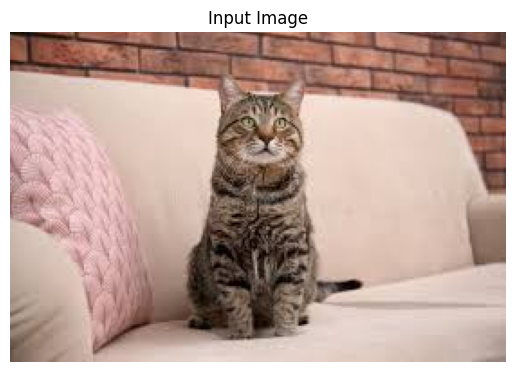

In [4]:
# Upload and Display Image
from google.colab import files

uploaded = files.upload()
image_path = list(uploaded.keys())[0]

image = Image.open(image_path).convert("RGB")

plt.figure()
plt.imshow(image)
plt.axis("off")
plt.title("Input Image")
plt.show()

In [5]:
# Preprocess Image for BLIP
inputs = processor(images=image, return_tensors="pt").to(device)

In [6]:
# Generate Caption
with torch.no_grad():
    output = model.generate(**inputs, max_length=30)

caption = processor.decode(output[0], skip_special_tokens=True)
print("Generated Caption:")
print(caption)

Generated Caption:
a cat sitting on a couch in a living room


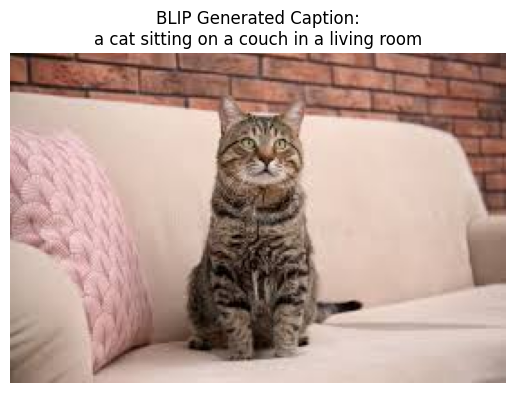

In [7]:
plt.figure()
plt.imshow(image)
plt.axis("off")
plt.title(f"BLIP Generated Caption:\n{caption}")
plt.show()